# Week 2

## Statistical Analysis

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'], inplace=True)
df_features = df.iloc[:, :-1]
df_target = df['DEATH_EVENT']

In [2]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,0


In [3]:
df_features

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0
...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1


In [4]:
df_features.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892


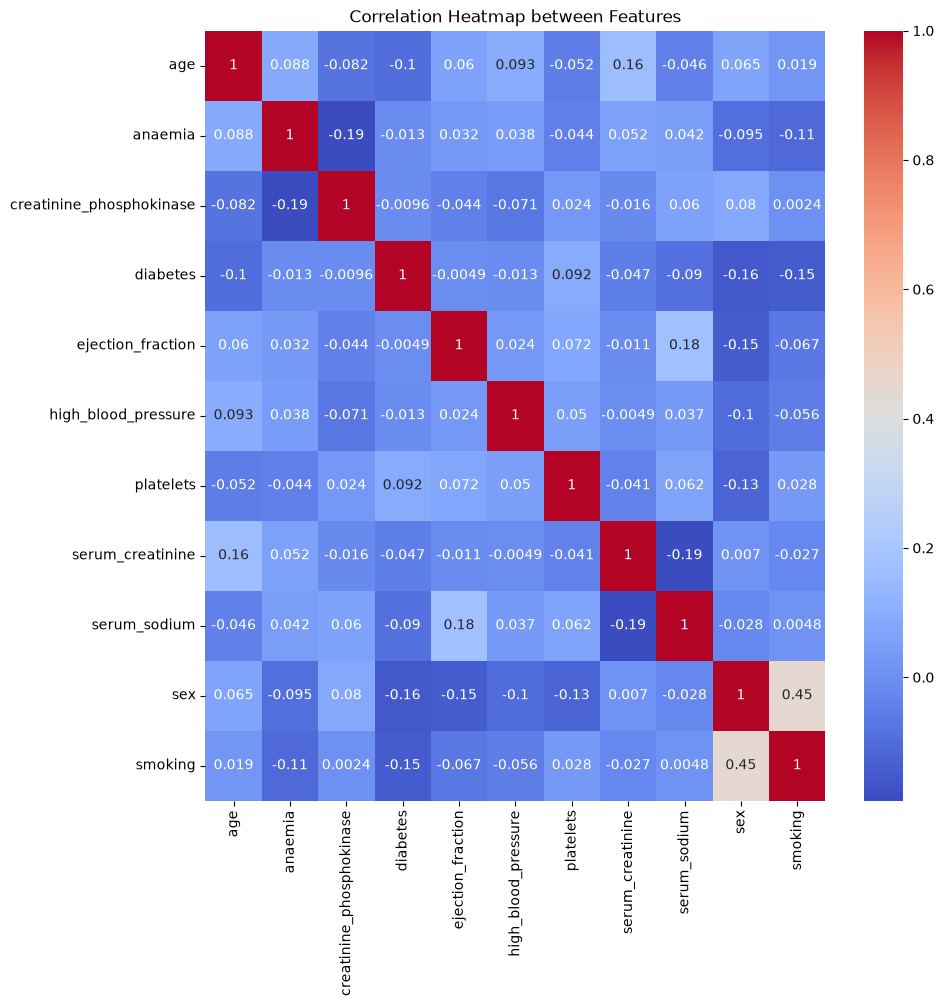

<Figure size 640x480 with 0 Axes>

In [5]:
correlation = df_features.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap between Features')

plt.show()

# clear plotting context to avoid replotting issues in some environments
plt.clf()

# Question: What is the next step you think we should take?






















# Exercise: Measure the correlation of the features with the output and visualize it. 

Hint: You can use pearsonr from scipy.stats and horizontal bar plots for visualizing the correlation of the features

In [6]:
from scipy.stats import pearsonr

features = []
correlations = []
p_values = []
target_var = 'DEATH_EVENT'

for column in df.columns:
    if column != target_var:
        corr, p_val = pearsonr(df[column], df[target_var])
        features.append(column)
        correlations.append(corr)
        p_values.append(p_val)

results_df = pd.DataFrame({
    'Feature': features,
    'Pearson Correlation': correlations,
    'P-value': p_values
})

results_df_sorted = results_df.sort_values(by='Pearson Correlation', ascending=False)

results_df_sorted

,Feature,Pearson Correlation,P-value
7,serum_creatinine,0.294278,2.190198e-07
0,age,0.253729,8.916763e-06
5,high_blood_pressure,0.079351,1.711495e-01
1,anaemia,0.066270,2.532988e-01
2,creatinine_phosphokinase,0.062728,2.796112e-01
3,diabetes,-0.001943,9.733118e-01
9,sex,-0.004316,9.407519e-01
10,smoking,-0.012623,8.279207e-01
6,platelets,-0.049139,3.971942e-01
8,serum_sodium,-0.195204,6.889112e-04


<BarContainer object of 11 artists>

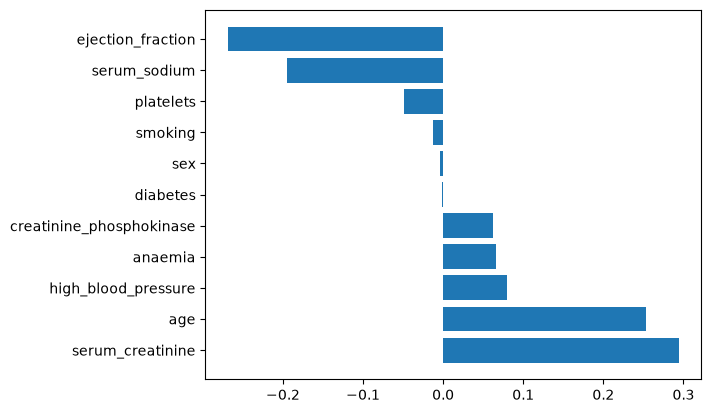

In [7]:
plt.barh(results_df_sorted['Feature'], results_df_sorted['Pearson Correlation'])

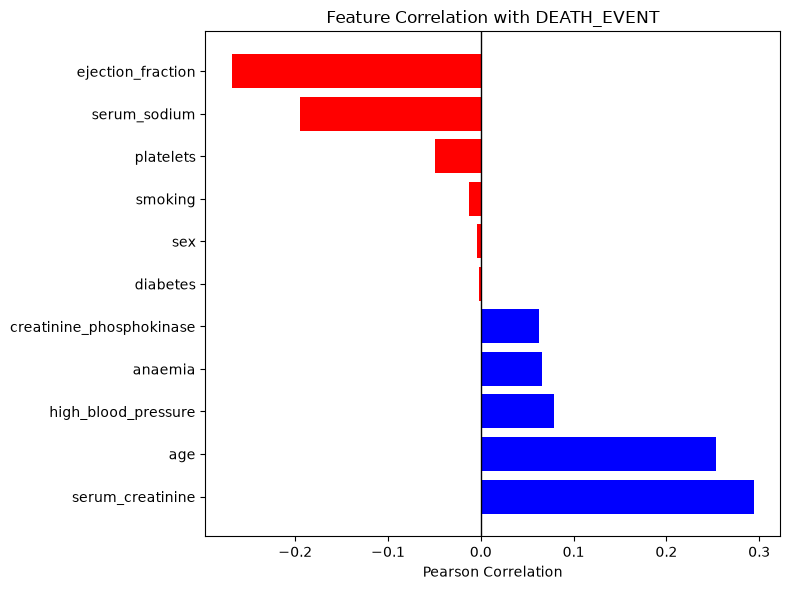

In [8]:
colors = ['red' if c < 0 else 'blue' for c in results_df_sorted['Pearson Correlation']]

plt.figure(figsize=(8, 6))
plt.barh(results_df_sorted['Feature'], results_df_sorted['Pearson Correlation'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Feature Correlation with DEATH_EVENT')
plt.xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

# Question: What do you think about most important features? 

In [9]:
from scipy.stats import ttest_ind

survived_group = df[df['DEATH_EVENT'] == 0]
death_group = df[df['DEATH_EVENT'] == 1]

results = {'Feature': [], 'T-Statistic': [], 'P-Value': []}

numerical_cols = df.select_dtypes(include=[np.number]).columns.drop(['DEATH_EVENT'])

for col in numerical_cols:
    t_stat, p_val = ttest_ind(survived_group[col], death_group[col], equal_var=False)
    results['Feature'].append(col)
    results['T-Statistic'].append(t_stat)
    results['P-Value'].append(p_val)

results_df = pd.DataFrame(results)

results_df

,Feature,T-Statistic,P-Value
0,age,-4.186210,0.000047
1,anaemia,-1.136898,0.257064
2,creatinine_phosphokinase,-0.901190,0.369216
3,diabetes,0.033458,0.973345
4,ejection_fraction,4.566983,0.000010
5,high_blood_pressure,-1.347390,0.179564
6,platelets,0.844785,0.399323
7,serum_creatinine,-4.152639,0.000064
8,serum_sodium,3.164501,0.001872
9,sex,0.074238,0.940901


# Exercise: Write a python function that returns a list including the features with significant P-value. This function should get 2 inputs: a dataframe (results_df) and a threshold

In [20]:
def get_significant_features(df, threshold=0.05):
    return df[df['P-Value'] < threshold]['Feature'].tolist()

print("Significant features (p<0.05):", get_significant_features(results_df, 0.05))

Significant features (p<0.05): ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium']


# Exercise: Write a python function to do mannwhitneyu test: 

hint: from scipy.stats import mannwhitneyu for all features

mannwhitneyu(survived_group['serum_creatinine'], death_group['serum_creatinine'])

In [ ]:
from scipy.stats import mannwhitneyu

mw_results = []
for col in df.select_dtypes(include=[np.number]).columns.drop(['DEATH_EVENT']):
    u_stat, p_val = mannwhitneyu(survived_group[col], death_group[col], alternative='two-sided')
    mw_results.append({'Feature': col, 'U-Statistic': u_stat, 'P-Value': p_val})

mw_df = pd.DataFrame(mw_results).sort_values('P-Value')
mw_df['Significant'] = mw_df['P-Value'] < 0.05
mw_df

,Feature,U-Statistic,P-Value,Significant
7,serum_creatinine,5298.0,1.580998e-10,True
4,ejection_fraction,13176.5,7.368249e-07,True
0,age,7121.0,1.667518e-04,True
8,serum_sodium,12261.5,2.927557e-04,True
5,high_blood_pressure,8953.5,1.710164e-01,False
1,anaemia,9059.0,2.529704e-01,False
6,platelets,10300.5,4.255585e-01,False
2,creatinine_phosphokinase,9460.0,6.840400e-01,False
10,smoking,9867.0,8.281900e-01,False
9,sex,9787.0,9.412922e-01,False


# Question: Is this enough to just perform the ttest or mannwhitney test?

In [12]:
from statsmodels.stats.multitest import multipletests

p_values = results_df['P-Value'].values
fdr = multipletests(p_values, method='fdr_bh')

results_df['p_fdr_bh'] = fdr[1]

results_df['significant_fdr'] = results_df['p_fdr_bh'] < 0.05

results_df.sort_values('p_fdr_bh')

,Feature,T-Statistic,P-Value,p_fdr_bh,significant_fdr
7,serum_creatinine,5298.0,1.580998e-10,1.739098e-09,True
4,ejection_fraction,13176.5,7.368249e-07,4.052537e-06,True
0,age,7121.0,1.667518e-04,6.114233e-04,True
8,serum_sodium,12261.5,2.927557e-04,8.050783e-04,True
5,high_blood_pressure,8953.5,1.710164e-01,3.762361e-01,False
1,anaemia,9059.0,2.529704e-01,4.637791e-01,False
6,platelets,10300.5,4.255585e-01,6.687348e-01,False
2,creatinine_phosphokinase,9460.0,6.840400e-01,9.405550e-01,False
3,diabetes,9764.0,9.739131e-01,9.739131e-01,False
9,sex,9787.0,9.412922e-01,9.739131e-01,False


# Feature Importance (Preview)

Note: This section provides a quick preview of ML-based feature ranking. We'll explore these techniques in more depth later in the project. For now, focus on understanding the statistical tests above.

## Random Forest

ML models can rank features by their predictive power. Here's a brief look at how Random Forest ranks our features.

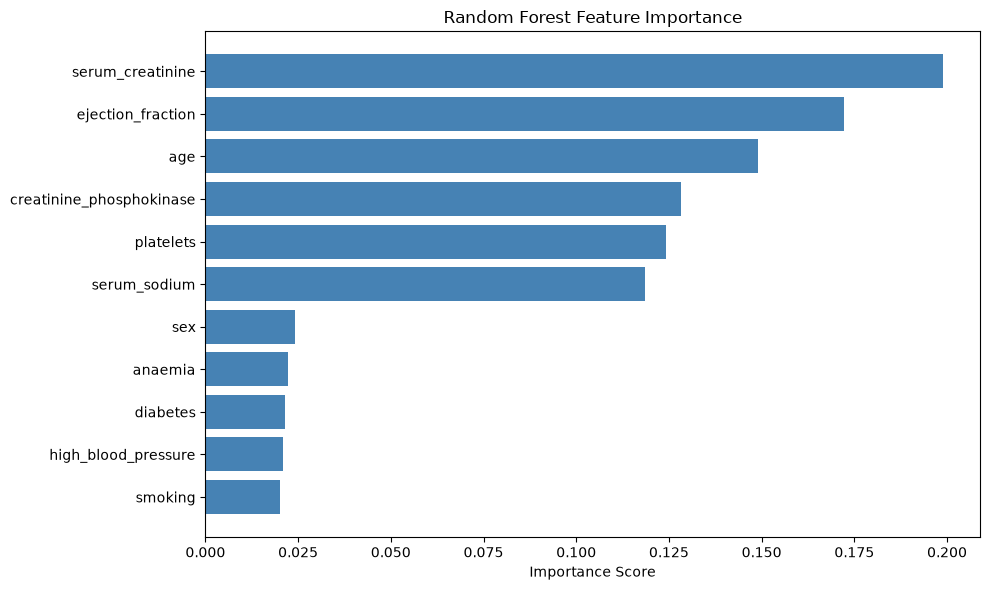

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

## Feature Variance Analysis

Features with very low variance may not be useful for prediction. This is supplementary material for those interested.

In [ ]:
from sklearn.preprocessing import StandardScaler

variance_df = pd.DataFrame({
    'Feature': X.columns,
    'Variance': X.var(),
    'Std': X.std(),
    'Mean': X.mean(),
    'CV': X.std() / X.mean()
}).sort_values('Variance', ascending=False)

print("Feature Variance Summary:")
print("CV (Coefficient of Variation) = Std/Mean (higher means more spread relative to mean)\n")

variance_df

Feature Variance Summary:
CV (Coefficient of Variation) = Std/Mean (higher means more spread relative to mean)



,Feature,Variance,Std,Mean,CV
platelets,platelets,9.565669e+09,97804.236869,263358.029264,0.371374
creatinine_phosphokinase,creatinine_phosphokinase,9.414586e+05,970.287881,581.839465,1.667621
age,age,1.414865e+02,11.894809,60.833893,0.195529
ejection_fraction,ejection_fraction,1.400635e+02,11.834841,38.083612,0.310759
serum_sodium,serum_sodium,1.946996e+01,4.412477,136.625418,0.032296
serum_creatinine,serum_creatinine,1.070211e+00,1.034510,1.393880,0.742180
anaemia,anaemia,2.461224e-01,0.496107,0.431438,1.149892
diabetes,diabetes,2.441023e-01,0.494067,0.418060,1.181808
high_blood_pressure,high_blood_pressure,2.286144e-01,0.478136,0.351171,1.361550
sex,sex,2.286144e-01,0.478136,0.648829,0.736922


# Summary

Key Takeaways from Week 2:

1. Correlation Analysis: Pearson correlation measures linear relationships between features and target
2. Statistical Tests: 
   - T-test: Compares means between two groups (assumes normality)
   - Mann-Whitney U: Non-parametric alternative (no normality assumption)
3. Multiple Testing Correction: FDR (Benjamini-Hochberg) adjusts p-values when testing many hypotheses
4. Significant Features: time, ejection_fraction, serum_creatinine, age, serum_sodium

Next Steps: Unsupervised learning approaches (PCA, clustering) in Week 3

# Resources

**Statistical Tests:**
- [Scipy Stats Documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [T-test vs Mann-Whitney U](https://www.statisticshowto.com/mann-whitney-u-test/)

**Multiple Testing Correction:**
- [Statsmodels Multipletests](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html)
- [FDR Explained](https://www.statisticshowto.com/false-discovery-rate/)

**Feature Importance:**
- [Scikit-learn Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

**Dataset:**
- [Heart Failure Clinical Records - UCI](https://archive.ics.uci.edu/ml/datasets/Heart+failure+clinical+records)